In [7]:
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv('../data/raw/load_train.csv')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245472 entries, 0 to 245471
Data columns (total 2 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Unnamed: 0   245472 non-null  object 
 1   Actual Load  245472 non-null  float64
dtypes: float64(1), object(1)
memory usage: 3.7+ MB


In [10]:
df.shape

(245472, 2)

In [11]:
df['DateTime'] = pd.to_datetime(df['Unnamed: 0'], utc=True)

In [12]:
df['DateTime'] = df['DateTime'].dt.tz_convert('Europe/Amsterdam')

In [13]:
df = df.drop(columns=['Unnamed: 0'])

In [14]:
df.head(10)

,Actual Load,DateTime
0,11267.78,2019-01-01 00:00:00+01:00
1,11279.78,2019-01-01 00:15:00+01:00
2,11287.25,2019-01-01 00:30:00+01:00
3,11304.48,2019-01-01 00:45:00+01:00
4,11265.80,2019-01-01 01:00:00+01:00
5,11251.71,2019-01-01 01:15:00+01:00
6,11184.59,2019-01-01 01:30:00+01:00
7,11072.44,2019-01-01 01:45:00+01:00
8,11042.94,2019-01-01 02:00:00+01:00
9,11001.69,2019-01-01 02:15:00+01:00


In [15]:
df.set_index('DateTime', inplace=True)

In [16]:
load = df.resample('h').mean()

In [17]:
load.shape

(61368, 1)

In [18]:
load.head()

,Actual Load
DateTime,
2019-01-01 00:00:00+01:00,11284.8225
2019-01-01 01:00:00+01:00,11193.6350
2019-01-01 02:00:00+01:00,10933.3600
2019-01-01 03:00:00+01:00,10666.5800
2019-01-01 04:00:00+01:00,10413.3575


In [19]:
load.isna().sum()

Actual Load    0
dtype: int64

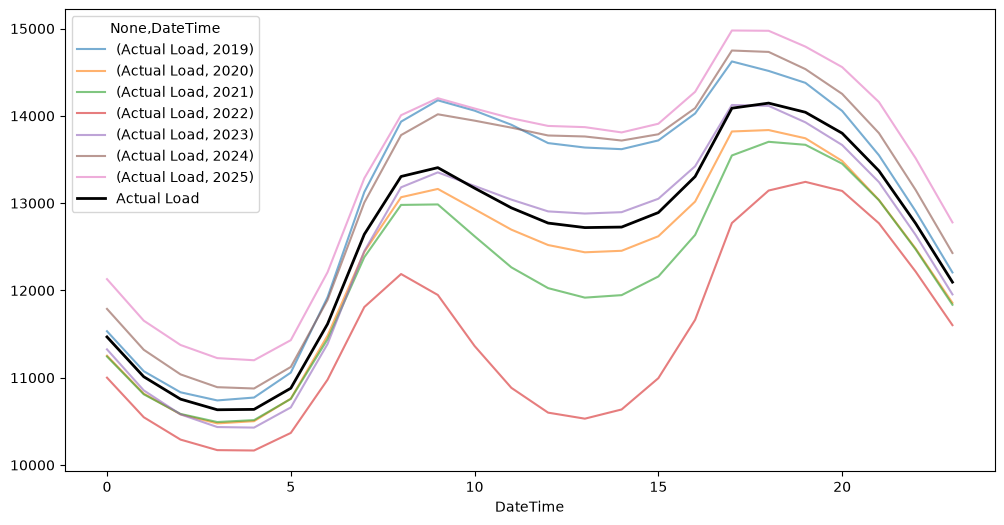

In [20]:
fig, ax = plt.subplots(figsize=(12, 6))
load.groupby([load.index.hour, load.index.year]).mean().unstack().plot(ax=ax, alpha=0.6)
load.groupby(load.index.hour).mean().plot(ax=ax, color='black', linewidth=2)
plt.show()

daily seasonality 

trough ~4am, rises to a morning peak ~8-9am, dips slightly midday, climbs to the daily peak ~6pm, then declines steadily overnight back to the trough.

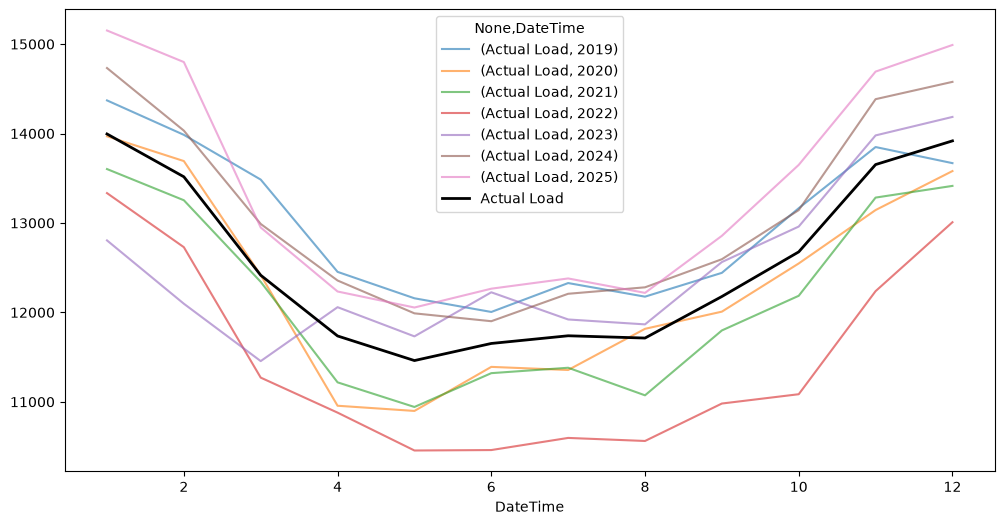

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))
load.groupby([load.index.month, load.index.year]).mean().unstack().plot(ax=ax, alpha=0.6)
load.groupby(load.index.month).mean().plot(ax=ax, color='black', linewidth=2)
plt.show()

annual seasonality

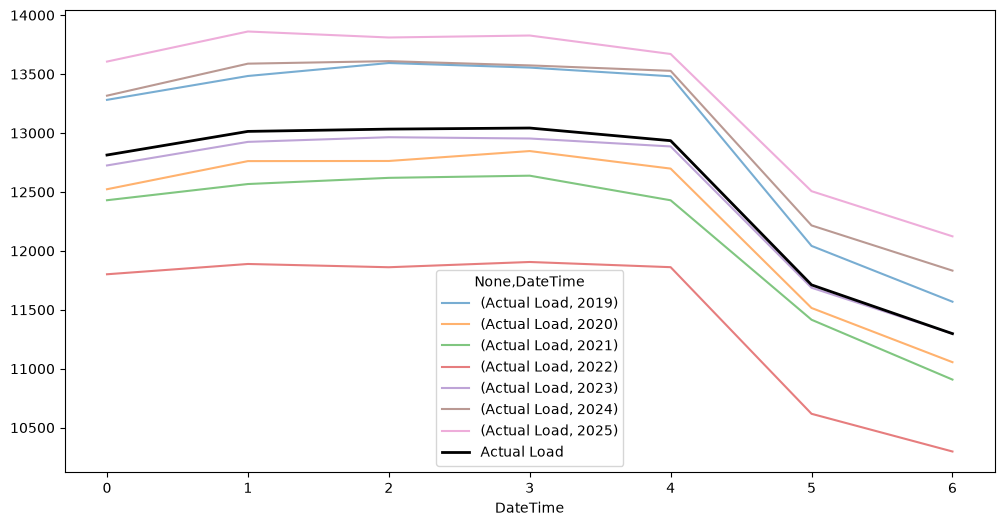

In [22]:
fig, ax = plt.subplots(figsize=(12, 6))
load.groupby([load.index.day_of_week, load.index.year]).mean().unstack().plot(ax=ax, alpha=0.6)
load.groupby(load.index.day_of_week).mean().plot(ax=ax, color='black', linewidth=2)
plt.show()

weekly seasonality

In [23]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

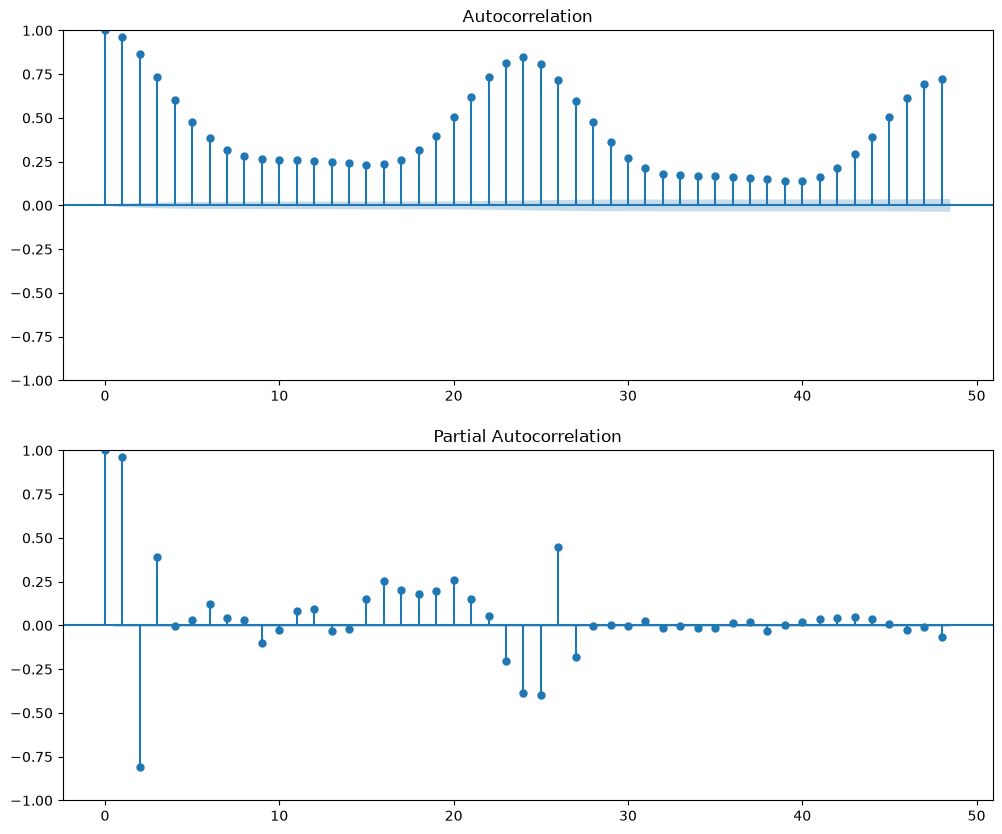

In [24]:
fig, ax = plt.subplots(2, 1, figsize=(12, 10))
plot_acf(load, lags=48, ax=ax[0], alpha=0.05)
plot_pacf(load, lags=48, ax=ax[1], alpha=0.05)
plt.show()

<Figure size 1200x600 with 0 Axes>

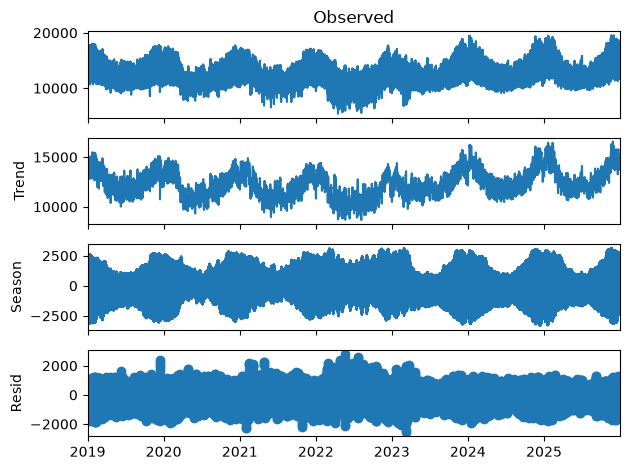

In [25]:
from statsmodels.tsa.seasonal import STL
plt.figure(figsize=(12, 6))
stl = STL(load, seasonal=13, period=24)
result = stl.fit()
result.plot()
plt.show()

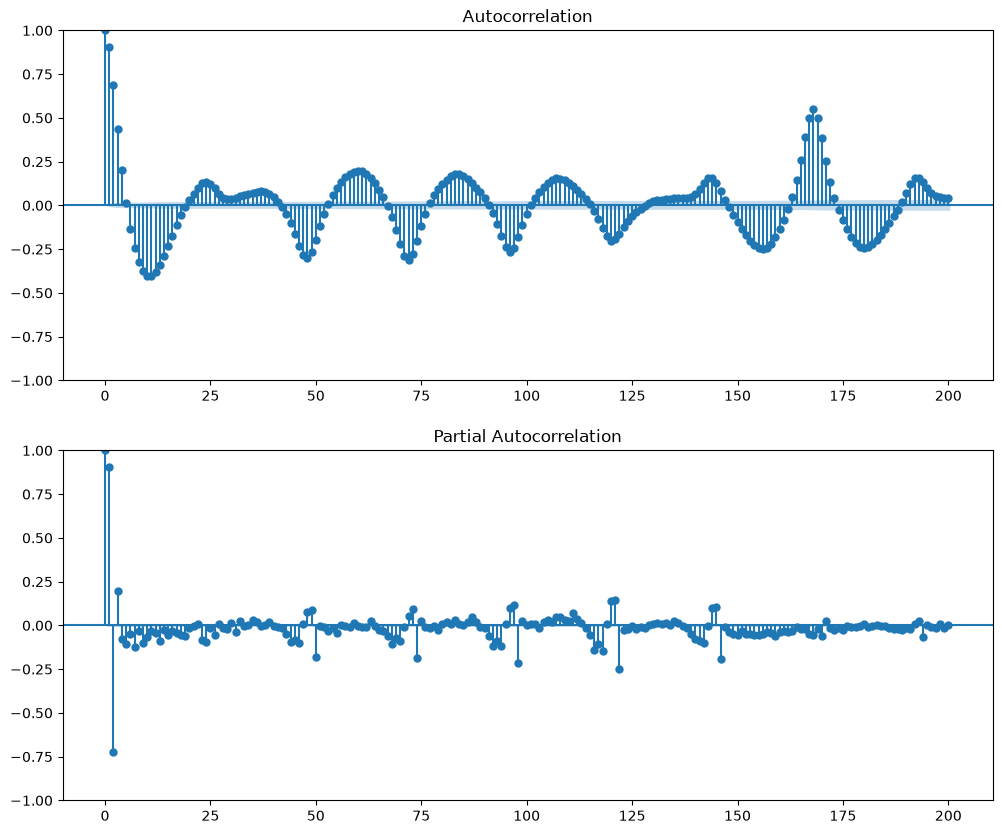

In [26]:
residuals = result.resid
fig, ax = plt.subplots(2, 1, figsize=(12, 10))
plot_acf(residuals, lags=200, ax=ax[0], alpha=0.05)
plot_pacf(residuals, lags=200, ax=ax[1], alpha=0.05)
plt.show()

1,2,3, 24 lag and datetime features like hour, day of the week, month

but 1,2,3 lag would not be present in direct forecasting

In [27]:
from sklearn.pipeline import make_union, make_pipeline
from sktime.transformations.summarize import WindowSummarizer
from feature_engine.datetime import DatetimeFeatures

In [28]:
ws = WindowSummarizer(target_cols=['Actual Load'], lag_feature={"mean": [[24, 24]], "lag": [24]}, n_jobs=1)

In [29]:
df_ws = ws.fit_transform(load)

In [30]:
dtf = DatetimeFeatures(variables="index",features_to_extract=['hour', 'day_of_week', 'month','weekend'])

In [31]:
df_dtf = dtf.fit_transform(df_ws)

In [32]:
df_dtf

,Actual Load_mean_24_24,Actual Load_lag_24,hour,day_of_week,month,weekend
DateTime,,,,,,
2019-01-01 00:00:00+01:00,NaN,NaN,0,1,1,0
2019-01-01 01:00:00+01:00,NaN,NaN,1,1,1,0
2019-01-01 02:00:00+01:00,NaN,NaN,2,1,1,0
2019-01-01 03:00:00+01:00,NaN,NaN,3,1,1,0
2019-01-01 04:00:00+01:00,NaN,NaN,4,1,1,0
...,...,...,...,...,...,...
2025-12-31 19:00:00+01:00,14932.784427,16744.98750,19,2,12,0
2025-12-31 20:00:00+01:00,14938.537833,16242.53900,20,2,12,0
2025-12-31 21:00:00+01:00,14942.283969,15442.39075,21,2,12,0


In [33]:
updated_load = pd.concat([df_dtf, load], axis=1)

In [34]:
updated_load.head(24)

,Actual Load_mean_24_24,Actual Load_lag_24,hour,day_of_week,month,weekend,Actual Load
DateTime,,,,,,,
2019-01-01 00:00:00+01:00,NaN,NaN,0,1,1,0,11284.8225
2019-01-01 01:00:00+01:00,NaN,NaN,1,1,1,0,11193.6350
2019-01-01 02:00:00+01:00,NaN,NaN,2,1,1,0,10933.3600
2019-01-01 03:00:00+01:00,NaN,NaN,3,1,1,0,10666.5800
2019-01-01 04:00:00+01:00,NaN,NaN,4,1,1,0,10413.3575
2019-01-01 05:00:00+01:00,NaN,NaN,5,1,1,0,10440.7925
2019-01-01 06:00:00+01:00,NaN,NaN,6,1,1,0,10669.5625
2019-01-01 07:00:00+01:00,NaN,NaN,7,1,1,0,10898.5625
2019-01-01 08:00:00+01:00,NaN,NaN,8,1,1,0,11161.1075


In [35]:
import holidays
nl_holidays = holidays.Netherlands(years=range(2019, 2027))

In [36]:
nl_holidays

{datetime.date(2019, 1, 1): "New Year's Day", datetime.date(2019, 4, 19): 'Good Friday', datetime.date(2019, 4, 21): 'Easter Sunday', datetime.date(2019, 4, 22): 'Easter Monday', datetime.date(2019, 4, 27): "King's Day", datetime.date(2019, 5, 30): 'Ascension Day', datetime.date(2019, 6, 9): 'Pentecost', datetime.date(2019, 6, 10): 'Pentecost Monday', datetime.date(2019, 12, 25): 'Christmas Day', datetime.date(2019, 12, 26): 'Second Day of Christmas', datetime.date(2020, 1, 1): "New Year's Day", datetime.date(2020, 4, 10): 'Good Friday', datetime.date(2020, 4, 12): 'Easter Sunday', datetime.date(2020, 4, 13): 'Easter Monday', datetime.date(2020, 4, 27): "King's Day", datetime.date(2020, 5, 5): 'Liberation Day', datetime.date(2020, 5, 21): 'Ascension Day', datetime.date(2020, 5, 31): 'Pentecost', datetime.date(2020, 6, 1): 'Pentecost Monday', datetime.date(2020, 12, 25): 'Christmas Day', datetime.date(2020, 12, 26): 'Second Day of Christmas', datetime.date(2021, 1, 1): "New Year's Day",

In [37]:
updated_load['is_holiday'] = [int(d in nl_holidays) for d in updated_load.index.date]

In [38]:
weekday_only = updated_load[updated_load['weekend'] == 0]

holiday_avg = weekday_only[weekday_only['is_holiday'] == 1]['Actual Load'].mean()
non_holiday_avg = weekday_only[weekday_only['is_holiday'] == 0]['Actual Load'].mean()

print(f"Weekday holiday avg load:     {holiday_avg:.0f}")
print(f"Weekday non-holiday avg load: {non_holiday_avg:.0f}")
print(f"Difference: {non_holiday_avg - holiday_avg:.0f} ({(non_holiday_avg-holiday_avg)/non_holiday_avg*100:.1f}%)")

Weekday holiday avg load:     11361
Weekday non-holiday avg load: 13012
Difference: 1651 (12.7%)


In [39]:
holiday_dates = weekday_only[weekday_only['is_holiday'] == 1].index.date
holiday_names = [nl_holidays.get(d) for d in holiday_dates]

per_holiday = weekday_only[weekday_only['is_holiday']==1].groupby(
    weekday_only[weekday_only['is_holiday']==1].index.date
).agg(load=('Actual Load','mean'))
per_holiday['name'] = [nl_holidays.get(d) for d in per_holiday.index]

per_holiday.groupby('name')['load'].mean().sort_values().to_frame().assign(
    pct_below_normal=lambda x: (non_holiday_avg - x['load'])/non_holiday_avg*100
)

,load,pct_below_normal
name,,
King's Day,9991.855130,23.210251
Pentecost Monday,10462.453780,19.593590
Ascension Day,10556.698393,18.869298
Easter Monday,10710.287827,17.688927
Liberation Day,10877.881354,16.400932
New Year's Day,12237.294958,5.953519
Good Friday,12244.719390,5.896461
Second Day of Christmas,12572.292781,3.378983
Christmas Day,12620.329438,3.009810


In [40]:
updated_load['holiday_name'] = [nl_holidays.get(d, 'none') for d in updated_load.index.date]
updated_load['holiday_name'] = updated_load['holiday_name'].astype('category')

In [41]:
updated_load.head()

,Actual Load_mean_24_24,Actual Load_lag_24,hour,day_of_week,month,weekend,Actual Load,is_holiday,holiday_name
DateTime,,,,,,,,,
2019-01-01 00:00:00+01:00,NaN,NaN,0,1,1,0,11284.8225,1,New Year's Day
2019-01-01 01:00:00+01:00,NaN,NaN,1,1,1,0,11193.6350,1,New Year's Day
2019-01-01 02:00:00+01:00,NaN,NaN,2,1,1,0,10933.3600,1,New Year's Day
2019-01-01 03:00:00+01:00,NaN,NaN,3,1,1,0,10666.5800,1,New Year's Day
2019-01-01 04:00:00+01:00,NaN,NaN,4,1,1,0,10413.3575,1,New Year's Day


In [42]:
updated_load = updated_load.dropna()

In [43]:
updated_load.head()

,Actual Load_mean_24_24,Actual Load_lag_24,hour,day_of_week,month,weekend,Actual Load,is_holiday,holiday_name
DateTime,,,,,,,,,
2019-01-02 23:00:00+01:00,12009.090937,11521.7475,23,2,1,0,12557.3975,0,none
2019-01-03 00:00:00+01:00,11999.559167,11056.0600,0,3,1,0,11983.2600,0,none
2019-01-03 01:00:00+01:00,11980.122604,10727.1575,1,3,1,0,11574.3100,0,none
2019-01-03 02:00:00+01:00,11965.111667,10573.0975,2,3,1,0,11283.6175,0,none
2019-01-03 03:00:00+01:00,11958.658125,10511.6950,3,3,1,0,11176.0000,0,none


In [44]:
updated_load.shape

(61321, 9)

In [45]:
weather_train = pd.read_csv("../data/raw/weather_train.csv", index_col=0, parse_dates=True)

load_train = pd.read_csv("../data/raw/load_train.csv", index_col=0, parse_dates=True)

weather_train.index = weather_train.index.tz_localize(
    "Europe/Amsterdam", nonexistent="shift_forward", ambiguous="NaT"
)

weather_train = weather_train[weather_train.index.notna()]
weather_train = weather_train[~weather_train.index.duplicated(keep="first")]

load_train = load_train[load_train.index.notna()]
load_train = load_train[~load_train.index.duplicated(keep="first")]

combined = pd.concat([load_train, weather_train], axis=1).dropna()

In [46]:
combined.head()

,Actual Load,temperature_2m,apparent_temperature,relative_humidity_2m,dew_point_2m,precipitation,rain,snowfall,snow_depth,cloud_cover,shortwave_radiation,direct_radiation,diffuse_radiation,wind_speed_10m,wind_gusts_10m,surface_pressure
2019-01-01 00:00:00+01:00,11267.78,8.4,4.8,87.0,6.3,0.0,0.0,0.0,0.0,90.0,0.0,0.0,0.0,18.3,32.0,1029.5
2019-01-01 01:00:00+01:00,11265.80,8.2,4.4,88.0,6.4,0.0,0.0,0.0,0.0,94.0,0.0,0.0,0.0,19.9,34.9,1029.0
2019-01-01 02:00:00+01:00,11042.94,8.1,4.1,90.0,6.5,0.0,0.0,0.0,0.0,94.0,0.0,0.0,0.0,20.7,36.7,1029.1
2019-01-01 03:00:00+01:00,10802.79,8.3,4.1,87.0,6.3,0.0,0.0,0.0,0.0,66.0,0.0,0.0,0.0,22.0,39.2,1028.8
2019-01-01 04:00:00+01:00,10443.23,7.9,3.6,87.0,5.9,0.0,0.0,0.0,0.0,71.0,0.0,0.0,0.0,22.3,39.6,1028.3


In [47]:
corr_with_load = combined.corr(numeric_only=True)["Actual Load"].drop("Actual Load").sort_values(key=abs, ascending=False)
print(corr_with_load)

apparent_temperature   -0.260572
temperature_2m         -0.248224
dew_point_2m           -0.220162
direct_radiation       -0.181111
cloud_cover             0.172437
shortwave_radiation    -0.144822
wind_gusts_10m          0.136329
wind_speed_10m          0.112547
surface_pressure       -0.107361
relative_humidity_2m    0.106745
snow_depth              0.064009
precipitation           0.062186
rain                    0.057144
snowfall                0.044522
diffuse_radiation      -0.025334
Name: Actual Load, dtype: float64


In [48]:
high_load_threshold = combined["Actual Load"].quantile(0.9)
high_load_subset = combined[combined["Actual Load"] >= high_load_threshold]

corr_high_load = high_load_subset.corr(numeric_only=True)["Actual Load"].drop("Actual Load").sort_values(key=abs, ascending=False)
print(corr_high_load)

temperature_2m         -0.262287
apparent_temperature   -0.249210
dew_point_2m           -0.242346
direct_radiation       -0.131169
shortwave_radiation    -0.123566
wind_speed_10m         -0.093073
diffuse_radiation      -0.082213
cloud_cover             0.064167
snowfall                0.054531
wind_gusts_10m         -0.046313
snow_depth              0.039490
surface_pressure        0.022983
rain                   -0.019973
relative_humidity_2m    0.018765
precipitation          -0.007608
Name: Actual Load, dtype: float64


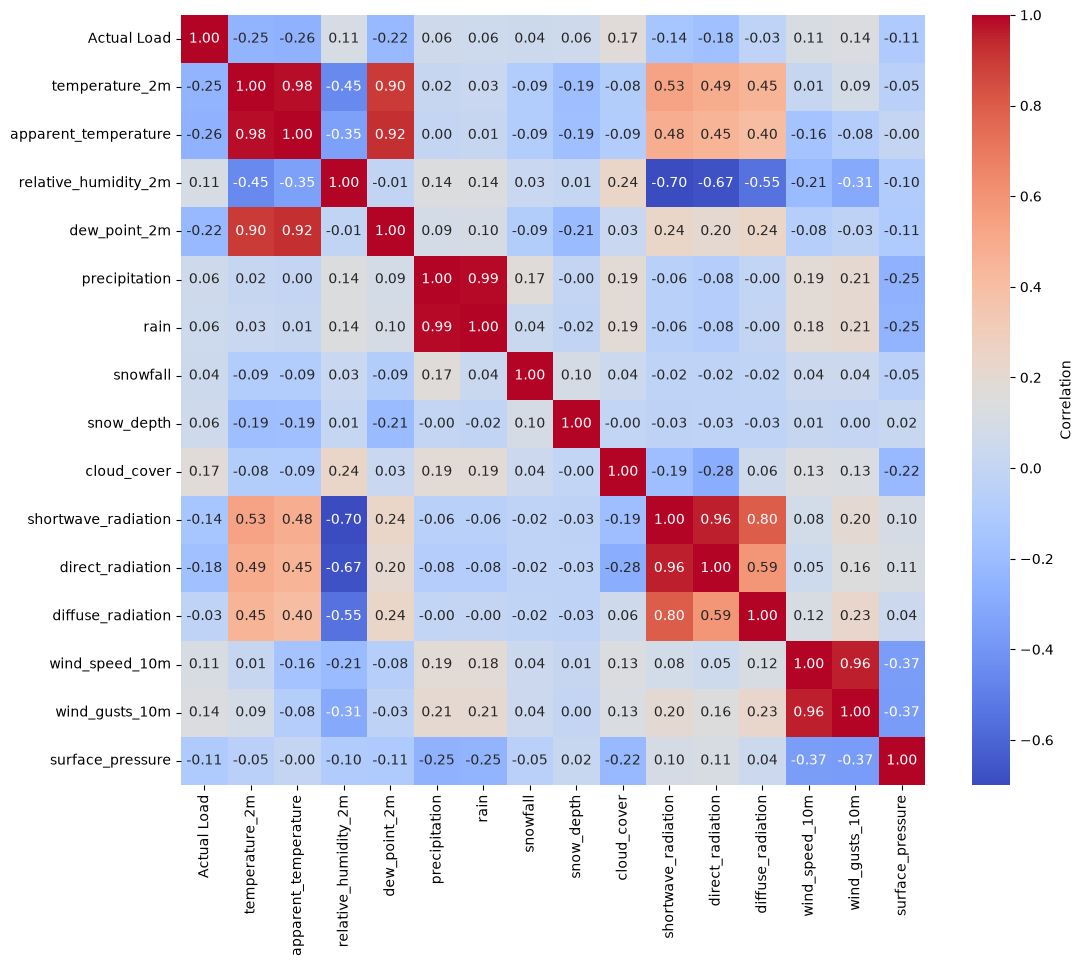

In [50]:
import seaborn as sns
plt.figure(figsize=(12, 10))
sns.heatmap(combined.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={"label": "Correlation"})
plt.show()

In [51]:
from entso_e_pipeline import storage

forecast = storage.fetch_forecasts()
print("Forecast rows:", len(forecast))
print(forecast.index.min(), "to", forecast.index.max())
print(forecast.tail())

actual = storage.fetch_load_actuals()
print("\nActual rows:", len(actual))
print(actual.index.min(), "to", actual.index.max())
print(actual.tail())

Forecast rows: 24
2026-08-18 00:00:00+02:00 to 2026-08-18 23:00:00+02:00
                                           forecast_made_at    point_pred  \
datetime                                                                    
2026-08-18 19:00:00+02:00  2026-08-18T01:07:46.709836+00:00  10567.168787   
2026-08-18 20:00:00+02:00  2026-08-18T01:07:46.709836+00:00  11342.547660   
2026-08-18 21:00:00+02:00  2026-08-18T01:07:46.709836+00:00  11360.784605   
2026-08-18 22:00:00+02:00  2026-08-18T01:07:46.709836+00:00  11430.329463   
2026-08-18 23:00:00+02:00  2026-08-18T01:07:46.709836+00:00  11145.036502   

                                    q10           q50           q90  \
datetime                                                              
2026-08-18 19:00:00+02:00   9734.250556  10625.338849  11998.929554   
2026-08-18 20:00:00+02:00  10327.820804  10585.802223  12086.155065   
2026-08-18 21:00:00+02:00  10770.867065  11013.412903  12108.503577   
2026-08-18 22:00:00+02:00  10810

In [52]:
from entso_e_pipeline.ingestion.weather import pull_weather
from entso_e_pipeline import config
import pandas as pd

yesterday = (pd.Timestamp.now(tz=config.TIMEZONE).normalize() - pd.Timedelta(days=1)).strftime("%Y-%m-%d")
print(f"Testing single day: {yesterday}")

df = pull_weather(yesterday, yesterday, variables=config.WEATHER_FEATURES)
print(df)

Testing single day: 2026-08-19
                     apparent_temperature  dew_point_2m
time                                                   
2026-08-19 00:00:00                  19.2          15.5
2026-08-19 01:00:00                  19.0          15.4
2026-08-19 02:00:00                  18.7          15.6
2026-08-19 03:00:00                  19.0          15.4
2026-08-19 04:00:00                  18.7          15.2
2026-08-19 05:00:00                  18.4          15.2
2026-08-19 06:00:00                  18.1          15.5
2026-08-19 07:00:00                  17.2          15.5
2026-08-19 08:00:00                  16.8          15.2
2026-08-19 09:00:00                  17.1          15.9
2026-08-19 10:00:00                  17.3          15.9
2026-08-19 11:00:00                  17.3          15.9
2026-08-19 12:00:00                  18.9          15.9
2026-08-19 13:00:00                  19.2          15.2
2026-08-19 14:00:00                  18.9          13.6
2026-08-19 15:00:

In [53]:
from entso_e_pipeline import storage
f = storage.fetch_forecasts(start="2026-08-21", end="2026-08-21")
print(f["forecast_made_at"].iloc[0])

2026-08-21T02:48:15.396043+00:00


In [54]:
from entso_e_pipeline import storage
a = storage.fetch_load_actuals(start="2026-08-21", end="2026-08-21")
print(a.describe())

       Actual Load
count       1.0000
mean    10068.9835
std            NaN
min     10068.9835
25%     10068.9835
50%     10068.9835
75%     10068.9835
max     10068.9835


In [55]:
from entso_e_pipeline import storage
a20 = storage.fetch_load_actuals(start="2026-08-20", end="2026-08-20")
print(len(a20))

1


In [56]:
from entso_e_pipeline import storage

forecast = storage.fetch_forecasts(start="2026-08-15")
actual = storage.fetch_load_actuals(start="2026-08-15")

print("=== Forecasts by day ===")
print(forecast.groupby(forecast.index.date).size())

print("\n=== Actuals by day ===")
print(actual.groupby(actual.index.date).size())

=== Forecasts by day ===
2026-08-21    24
2026-08-22    24
dtype: int64

=== Actuals by day ===
2026-08-15    22
2026-08-16    24
2026-08-17    24
2026-08-18    24
2026-08-19    24
2026-08-20    24
2026-08-21    24
dtype: int64


In [57]:
from entso_e_pipeline import storage

f = storage.fetch_forecasts(start="2026-08-21", end="2026-08-21")
a = storage.fetch_load_actuals(start="2026-08-21", end="2026-08-21")

print("FORECAST timestamps:")
print(list(f.index))
print("\nACTUAL timestamps:")
print(list(a.index))

FORECAST timestamps:
[Timestamp('2026-08-21 02:00:00+0200', tz='Europe/Amsterdam')]

ACTUAL timestamps:
[Timestamp('2026-08-21 02:00:00+0200', tz='Europe/Amsterdam')]


In [58]:
import pandas as pd
from entso_e_pipeline import storage, config

start = pd.Timestamp("2026-08-21", tz=config.TIMEZONE).tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")
end = (pd.Timestamp("2026-08-21", tz=config.TIMEZONE) + pd.Timedelta(hours=23)).tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")

print("start:", start)
print("end:", end)

f = storage.fetch_forecasts(start=start, end=end)
print(len(f))

start: 2026-08-20T22:00:00Z
end: 2026-08-21T21:00:00Z
24


In [59]:
import pandas as pd
print(pd.Timestamp("2026-08-23", tz="Europe/Amsterdam").day_of_week, pd.Timestamp("2026-08-23", tz="Europe/Amsterdam").dayofweek)

6 6
